In [1]:
from itertools import product
from tqdm import tqdm
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
plt.rcParams.update({
    "mathtext.fontset": "cm",   # Computer Modern
    "font.family": "serif"
})

import numpy as np

from solver import Solver

def driver(a1, a2, a3, etaf_guess, f_start = 1e-4, state_space=1):
    solver = Solver(a1, a2, a3, Q0, epsilon)
    return solver.find_etaf(etaf_guess,f_start=f_start, state_space=state_space, fp_condition=-10)

epsilon = 1
Q0 = 0.1

param_set = [
            [2, 1/4,   3/4],
            [4, 1/6,   5/6],
            [6, 1/8,   7/8],
            [8, 11/10, 9/10]
            ]


etaf_guess = 0.4
fstart = 1e-2

sols = []
for params in tqdm(param_set):
    a1, gamma, omega = params
    a2 = a3 = a1 + 1
    sols.append(driver(a1, a2, a3, etaf_guess=etaf_guess, f_start = fstart))
    print(sols[-1].a1, sols[-1].a2, sols[-1].a3, sols[-1].eta_f, sols[-1].x[0][0])

 25%|██▌       | 1/4 [00:00<00:01,  2.79it/s]

2 3 3 0.3514012353479006 0.41823518056535813


 50%|█████     | 2/4 [00:01<00:01,  1.53it/s]

4 5 5 0.2036743404160951 0.6064366302075562


 75%|███████▌  | 3/4 [00:02<00:00,  1.05it/s]

6 7 7 0.16043990428642682 0.7171840853191608


100%|██████████| 4/4 [00:03<00:00,  1.21it/s]

8 9 9 0.14169827828736706 0.7843387081122218


954
1415
2386
2334


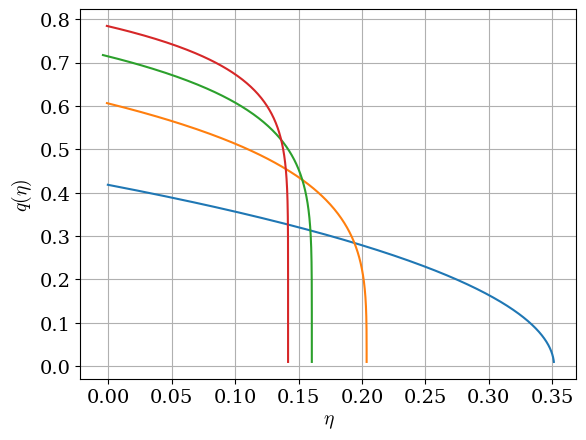

In [2]:
fig, ax = plt.subplots()
for sol,params in zip(sols, param_set):
    print(len(sol.eta))
    ax.plot(sol.eta, sol.x[0], label = "$\\alpha_1 = {}, \\gamma = {}, \\omega = {}$".format(*params))
    # ax.text(0, sol.x[0][0], "$f(0) = {:.4f}$".format(sol.x[0][0]))
    # ax.text(sol.eta[-1], fstart, "$\\eta_f = {:.4f}$".format(sol.eta_f))

ax.set_ylabel("$f(\\eta)$")
ax.set_ylabel("$q(\\eta)$")
ax.grid()
ax.set_xlabel("$\\eta$");


In [3]:
import pickle 
with open("plots\sol1.pkl", 'wb') as f:
    pickle.dump(sols, f)
